# Lab 02: Multiple Linear Regression, Cross Validation & Polynomial Regression
---
Implements from scratch using NumPy:
- **Part A** — Linear regression with multiple variables (CCPP dataset)
- **Part B** — 5-fold cross validation
- **Part C** — Polynomial regression with a single variable (data_02b.csv)

All algorithms use vectorized NumPy operations and gradient descent (no scikit-learn).

## Section 1: Import Libraries & Configuration

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ─────────────────────────── Configuration ──────────────────────────────────

BASE_DIR = os.path.dirname(os.path.abspath("__file__"))
PLOTS_DIR = os.path.join(BASE_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

CCPP_CONFIG = {
    "file_path": os.path.join(BASE_DIR, "CCPP", "CCPP", "Folds5x2_pp.xlsx"),
    "feature_names": ["AT (Temperature)", "V (Exhaust Vacuum)",
                      "AP (Ambient Pressure)", "RH (Relative Humidity)"],
    "target_name": "PE (Net Energy Output)",
    "learning_rate": 0.01,
    "iterations": 1500,
    "train_ratio": 0.8,
}

POLY_CONFIG = {
    "file_path": os.path.join(BASE_DIR, "data_02b.csv"),
    "learning_rate": 0.01,
    "iterations": 2000,
    "degrees": [1, 2, 3],
    "train_ratio": 0.8,
}

print("[INFO] Libraries imported and configuration set.")
print(f"[INFO] CCPP file : {CCPP_CONFIG['file_path']}")
print(f"[INFO] Poly file : {POLY_CONFIG['file_path']}")
print(f"[INFO] Plots dir : {PLOTS_DIR}")

[INFO] Libraries imported and configuration set.
[INFO] CCPP file : d:\Downloads\DUCSE Documents\4-1\Mine\CSE-4125 Introduction to Machine Learning\Lab\CSE-4125-Introduction-to-Machine-Learning\lab2\CCPP\CCPP\Folds5x2_pp.xlsx
[INFO] Poly file : d:\Downloads\DUCSE Documents\4-1\Mine\CSE-4125 Introduction to Machine Learning\Lab\CSE-4125-Introduction-to-Machine-Learning\lab2\data_02b.csv
[INFO] Plots dir : d:\Downloads\DUCSE Documents\4-1\Mine\CSE-4125 Introduction to Machine Learning\Lab\CSE-4125-Introduction-to-Machine-Learning\lab2\plots


## Section 2: Data Loading Functions

In [12]:
def load_ccpp_data(filepath):
    """
    Load the CCPP dataset from an Excel file (first sheet).

    Returns:
        X : (m, 4) array of features [AT, V, AP, RH]
        y : (m,)   array of target values [PE]
    """
    import openpyxl
    wb = openpyxl.load_workbook(filepath, read_only=True, data_only=True)
    ws = wb[wb.sheetnames[0]]

    data = []
    for i, row in enumerate(ws.iter_rows(values_only=True)):
        if i == 0:
            continue  # skip header
        data.append([float(v) for v in row])
    wb.close()

    data = np.array(data)
    X = data[:, :4] # first 4 cols = features [AT, V, AP, RH]
    y = data[:, 4]  # 5th col = target [PE]
    print(f"[INFO] Loaded CCPP data: {X.shape[0]} samples, {X.shape[1]} features")
    return X, y


def load_csv_data(filepath):
    """
    Load a CSV file with no header. Returns feature(s) and target.

    Returns:
        x : (m,) feature array
        y : (m,) target array
    """
    data = np.loadtxt(filepath, delimiter=",")
    x = data[:, 0] # feature column
    y = data[:, 1] # target column
    print(f"[INFO] Loaded {x.shape[0]} samples from {os.path.basename(filepath)}")
    return x, y


print("[INFO] Data loading functions defined.")

[INFO] Data loading functions defined.


## Section 3: Core ML Functions

These are the fundamental building blocks used across all three parts:
- `train_test_split` — shuffle & split into 80/20 train/val
- `normalize_features` — Z-score using training stats only
- `add_bias` — prepend a column of ones for the intercept term
- `compute_cost` — MSE: $J(\theta) = \frac{1}{2m}\|X\theta - y\|^2$
- `gradient_descent` — batch update: $\theta := \theta - \frac{\alpha}{m} X^\top(X\theta - y)$
- `train_model` — initializes $\theta$ to zero and runs gradient descent
- `k_fold_split` — generator yielding k train/val splits
- `build_polynomial_features` — creates $[x, x^2, \ldots, x^d]$ matrix

In [ ]:
def train_test_split(X, y, train_ratio=0.8, seed=42):
    """
    Shuffle and split data into training and validation sets.

    Returns:
        X_train, y_train, X_val, y_val
    """
    m = X.shape[0] # X.shape returns (rows, cols). X.shape[0] is the number of rows = number of samples. For CCPP: m = 9568.
    np.random.seed(seed) 
    indices = np.random.permutation(m) # shuffle indices
    split = int(m * train_ratio) # Computes the cutoff index. e.g. 80% of 9568 = 7654 

    train_idx = indices[:split] # first 7654 shuffled indices
    val_idx = indices[split:] # last 1914 shuffled indices

    return X[train_idx], y[train_idx], X[val_idx], y[val_idx] 
    # returns X_train, y_train, X_val, y_val --> Training features, Training targets, Validation features, Validation targets

def normalize_features(X_train, X_val=None):
    """
    Z-score normalization: (x - mean) / std. --> (X_train - mu) / sigma

    Computes statistics from X_train only, applies to both sets.
    This prevents data leakage from the validation set.

    Returns:
        X_train_norm, X_val_norm (or None), norm_params dict
    """
    mu = np.mean(X_train, axis=0)
    sigma = np.std(X_train, axis=0)
    sigma[sigma == 0] = 1  # avoid division by zero

    X_train_norm = (X_train - mu) / sigma # (x - mean) / std. --> (X_train - mu) / sigma
    X_val_norm = (X_val - mu) / sigma if X_val is not None else None

    norm_params = {"mean": mu, "std": sigma}
    return X_train_norm, X_val_norm, norm_params


def add_bias(X):
    """Prepend a column of ones (bias term) to the design matrix.
    
    Transforms X from shape (m, n) → (m, n+1)
    so that θ₀ is handled naturally inside the matrix multiply.
    """
    m = X.shape[0]
    return np.column_stack((np.ones(m), X))


def compute_cost(X, y, theta):
    """
    Mean Squared Error cost: J(θ) = (1 / 2m) * ||Xθ - y||²

    Parameters:
        X     : (m, n) design matrix (with bias column)
        y     : (m, 1) target vector
        theta : (n, 1) parameter vector

    Returns:
        cost : scalar
    """
    m = X.shape[0] # X.shape returns (rows, cols). X.shape[0] is the number of rows = number of samples.
    errors = X @ theta - y # calculating --> ||Xθ - y||
    return (1.0 / (2 * m)) * np.sum(errors ** 2) # Mean Squared Error cost: J(θ) = (1 / 2m) * ||Xθ - y||²


def gradient_descent(X, y, theta, alpha, num_iters, X_val=None, y_val=None):
    """
    Batch gradient descent with optional validation tracking.

    Update rule: θ := θ - (α / m) * Xᵀ(Xθ - y)

    Parameters:
        X, y       : training data and targets
        theta      : (n, 1) initial parameters
        alpha      : learning rate
        num_iters  : number of iterations
        X_val/y_val: optional validation set for monitoring

    Returns:
        theta        : (n, 1) learned parameters
        train_costs  : list of training cost per iteration
        val_costs    : list of validation cost per iteration (empty if no val set)
    """
    m = X.shape[0] # X.shape returns (rows, cols). X.shape[0] is the number of rows = number of samples.
    train_costs = []
    val_costs = []

    for _ in range(num_iters):
        predictions = X @ theta # calculating --> Xθ
        errors = predictions - y # calculating --> Xθ - y
        gradient = (1.0 / m) * (X.T @ errors) # calculating --> (α / m) * Xᵀ(Xθ - y)
        theta = theta - alpha * gradient # Update rule: θ := θ - (α / m) * Xᵀ(Xθ - y)

        train_costs.append(compute_cost(X, y, theta)) # compute_cost --> Mean Squared Error cost: J(θ) = (1 / 2m) * ||Xθ - y||²
        if X_val is not None:
            val_costs.append(compute_cost(X_val, y_val, theta))

    return theta, train_costs, val_costs


def train_model(X_train, y_train, X_val=None, y_val=None,
                alpha=0.01, num_iters=1000):
    """
    Train a linear regression model using gradient descent.

    Initializes θ to zeros (safe since MSE is convex → always reaches global minimum).

    Returns:
        theta, train_costs, val_costs
    """
    n = X_train.shape[1]
    theta = np.zeros((n, 1))

    theta, train_costs, val_costs = gradient_descent(
        X_train, y_train, theta, alpha, num_iters, X_val, y_val
    )

    print(f"[TRAIN] Final training cost   = {train_costs[-1]:.6f}")
    if val_costs:
        print(f"[TRAIN] Final validation cost = {val_costs[-1]:.6f}")

    return theta, train_costs, val_costs


def k_fold_split(X, y, k=5, seed=42):
    """
    Generator yielding k train/val splits for cross validation.

    Each fold uses a different 1/k chunk as validation,
    the remaining (k-1)/k chunks as training.

    Yields:
        (X_train, y_train, X_val, y_val) for each fold
    """
    m = X.shape[0]
    np.random.seed(seed)
    indices = np.random.permutation(m)
    fold_size = m // k

    for i in range(k):
        val_start = i * fold_size
        val_end = val_start + fold_size if i < k - 1 else m
        val_idx = indices[val_start:val_end]
        train_idx = np.concatenate([indices[:val_start], indices[val_end:]])
        yield X[train_idx], y[train_idx], X[val_idx], y[val_idx]


def build_polynomial_features(x, degree):
    """
    Create polynomial feature matrix [x, x², ..., x^d].

    Transforms 1D array x into a matrix of powers.
    Bias is NOT added here — call add_bias() separately.

    Returns:
        X_poly : (m, degree) feature matrix
    """
    m = x.shape[0]
    X_poly = np.zeros((m, degree))
    for d in range(1, degree + 1):
        X_poly[:, d - 1] = x ** d
    return X_poly


print("[INFO] All core ML functions defined.")

[INFO] All core ML functions defined.


## Section 4: Plotting Utilities

In [7]:
def plot_feature_vs_target(X, y, feature_names, target_name, save_prefix=None):
    """Plot each feature against the target variable (2x2 grid of subplots)."""
    n_features = X.shape[1]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i in range(n_features):
        ax = axes[i]
        ax.scatter(X[:, i], y, s=5, alpha=0.3, edgecolors='none')
        ax.set_xlabel(feature_names[i])
        ax.set_ylabel(target_name)
        ax.set_title(f"{feature_names[i]} vs {target_name}")
        ax.grid(True, alpha=0.3)

    plt.suptitle("Individual Features vs Target Variable", fontsize=14, y=1.01)
    plt.tight_layout()
    if save_prefix:
        path = os.path.join(PLOTS_DIR, f"{save_prefix}_features_vs_target.png")
        plt.savefig(path, dpi=150, bbox_inches="tight")
        print(f"[INFO] Plot saved: {path}")
    plt.show()


def plot_error_curves(train_costs, val_costs, title="Error Curves", save_as=None):
    """Plot training and validation cost vs. iterations."""
    plt.figure(figsize=(10, 6))
    iters = range(1, len(train_costs) + 1)
    plt.plot(iters, train_costs, label="Training Error", linewidth=1.5)
    if val_costs:
        plt.plot(iters, val_costs, label="Validation Error", linewidth=1.5)
    plt.xlabel("Iteration")
    plt.ylabel("Cost J(θ)")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_as:
        path = os.path.join(PLOTS_DIR, save_as)
        plt.savefig(path, dpi=150)
        print(f"[INFO] Plot saved: {path}")
    plt.show()


def plot_scatter(x, y, xlabel="x", ylabel="y", title="Data", save_as=None):
    """Simple scatter plot."""
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, s=15, alpha=0.6)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_as:
        path = os.path.join(PLOTS_DIR, save_as)
        plt.savefig(path, dpi=150)
        print(f"[INFO] Plot saved: {path}")
    plt.show()


def print_parameters(theta, label=""):
    """Pretty-print learned parameters."""
    print(f"\n{'=' * 55}")
    print(f"  LEARNED PARAMETERS {label}")
    print(f"{'=' * 55}")
    for i, val in enumerate(theta.flatten()):
        print(f"  theta_{i:<2d} = {val:>14.6f}")
    print(f"{'=' * 55}\n")


print("[INFO] Plotting utilities defined.")

[INFO] Plotting utilities defined.


## Section 5: Part A — Linear Regression with Multiple Variables (CCPP)

**Dataset:** Combined Cycle Power Plant — 9568 samples, 4 features, 1 target.

| Feature | Description |
|---|---|
| AT | Ambient Temperature |
| V | Exhaust Vacuum |
| AP | Ambient Pressure |
| RH | Relative Humidity |
| **PE** | **Net Hourly Electrical Energy Output (target)** |

**Steps:**
1. Load and visualize features vs target
2. Split 80% train / 20% validation
3. Train **without** normalization (requires tiny lr=1e-7)
4. Train **with** Z-score normalization (lr=0.01)
5. Compare both: normalization enables much faster convergence and lower cost


  PART A: LINEAR REGRESSION WITH MULTIPLE VARIABLES (CCPP)

[INFO] Loaded CCPP data: 9568 samples, 4 features
[INFO] Plot saved: d:\Downloads\DUCSE Documents\4-1\Mine\CSE-4125 Introduction to Machine Learning\Lab\CSE-4125-Introduction-to-Machine-Learning\lab2\plots\partA_features_vs_target.png


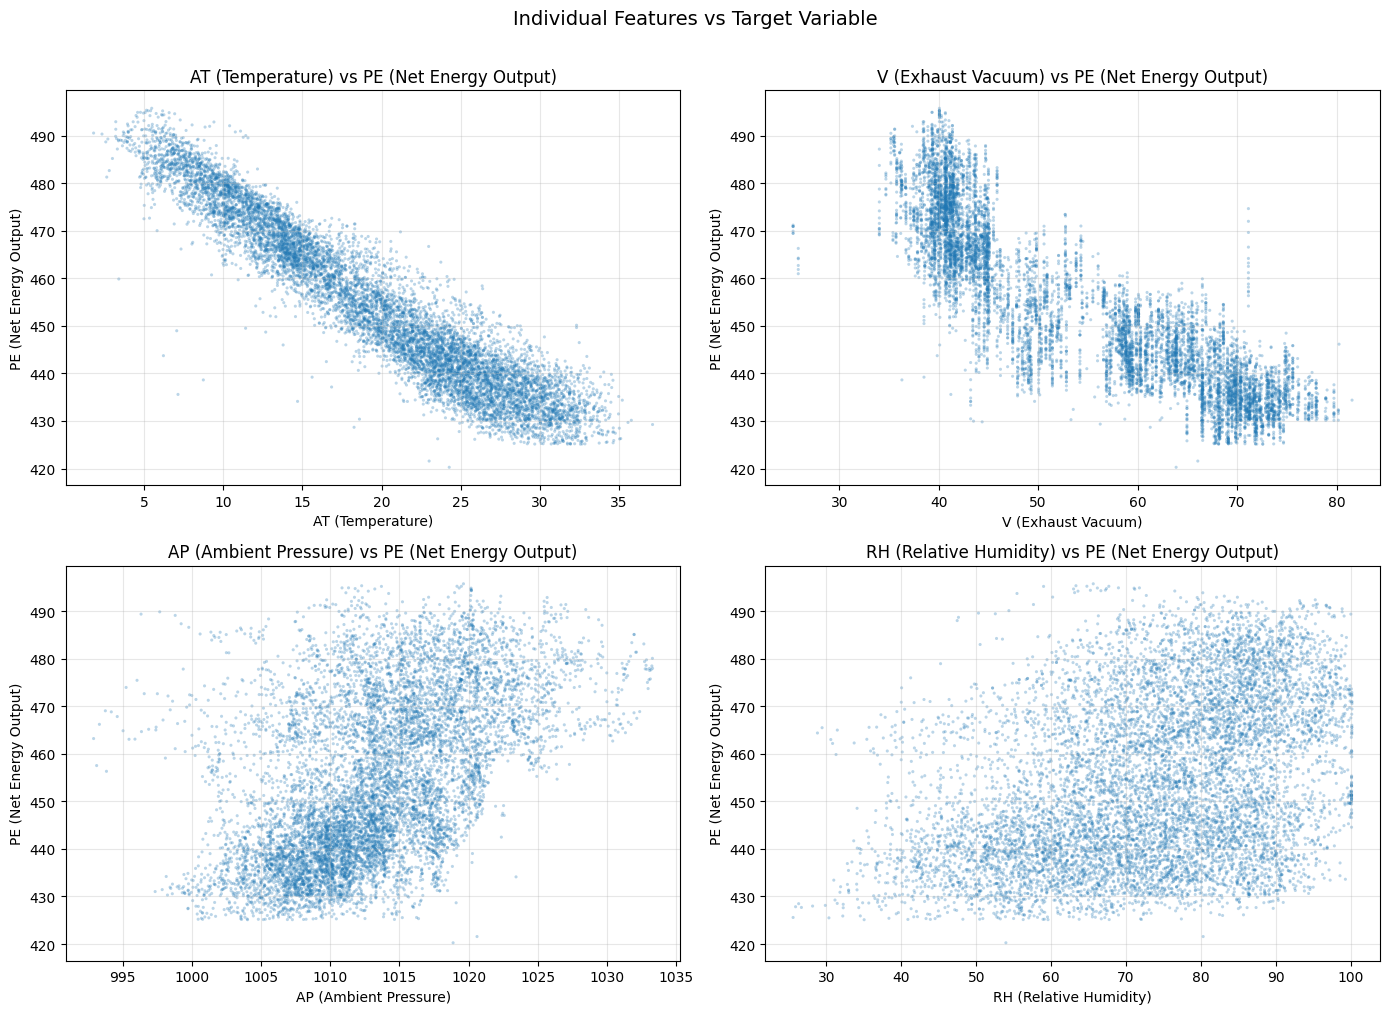


--- Without Feature Normalization ---
[TRAIN] Final training cost   = 120.621346
[TRAIN] Final validation cost = 119.860763
  Best validation cost (no norm)  = 119.860763

  LEARNED PARAMETERS (without normalization)
  theta_0  =       0.000434
  theta_1  =      -0.007891
  theta_2  =      -0.002618
  theta_3  =       0.445536
  theta_4  =       0.044634

[INFO] Plot saved: d:\Downloads\DUCSE Documents\4-1\Mine\CSE-4125 Introduction to Machine Learning\Lab\CSE-4125-Introduction-to-Machine-Learning\lab2\plots\partA_error_no_norm.png


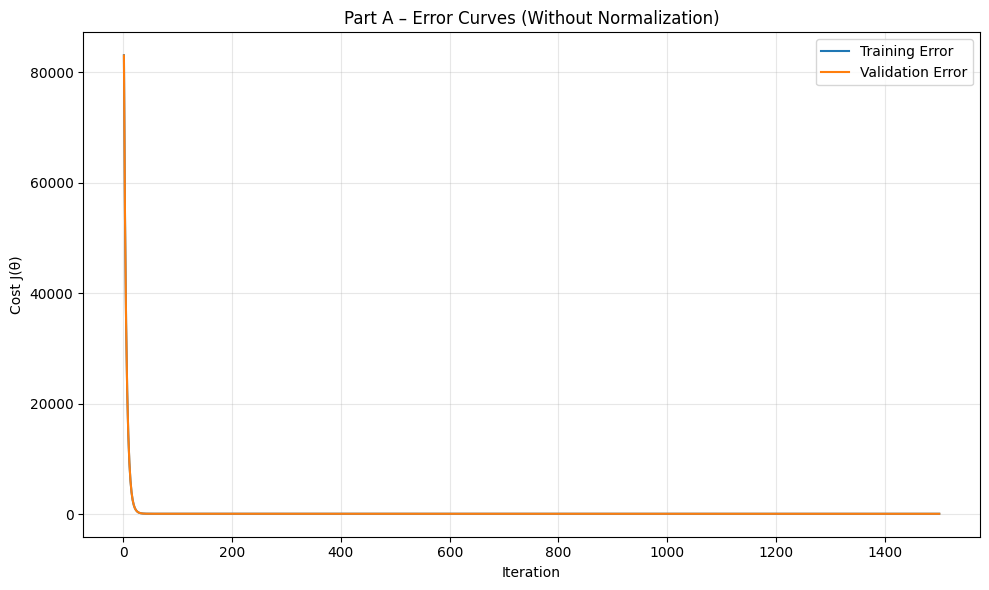


--- With Feature Normalization ---
[TRAIN] Final training cost   = 10.707300
[TRAIN] Final validation cost = 10.354387
  Best training cost   (norm)  = 10.707300
  Best validation cost (norm)  = 10.354387

  LEARNED PARAMETERS (with normalization)
  theta_0  =     454.391191
  theta_1  =     -13.042431
  theta_2  =      -4.210818
  theta_3  =       0.719397
  theta_4  =      -1.752833

[INFO] Plot saved: d:\Downloads\DUCSE Documents\4-1\Mine\CSE-4125 Introduction to Machine Learning\Lab\CSE-4125-Introduction-to-Machine-Learning\lab2\plots\partA_error_norm.png


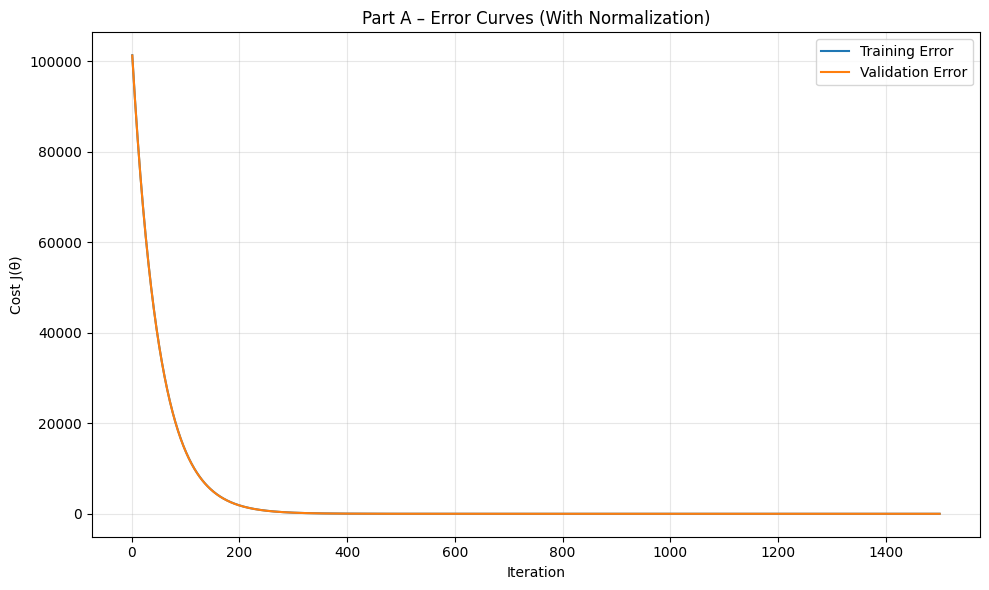


───────────────────────────────────────────────────────
  NORMALIZATION COMPARISON
───────────────────────────────────────────────────────
  Without normalization (lr=1e-07):
    Final train cost = 120.621346
    Final val   cost = 119.860763
  With normalization    (lr=0.01):
    Final train cost = 10.707300
    Final val   cost = 10.354387
───────────────────────────────────────────────────────



In [15]:
def run_part_a():
    """Part A: Multi-variable linear regression on the CCPP dataset."""
    cfg = CCPP_CONFIG
    print("\n" + "=" * 65)
    print("  PART A: LINEAR REGRESSION WITH MULTIPLE VARIABLES (CCPP)")
    print("=" * 65 + "\n")

    # ── 1. Load data ──
    X_raw, y_raw = load_ccpp_data(cfg["file_path"])

    # ── 2. Plot individual features vs target ──
    plot_feature_vs_target(
        X_raw, y_raw,
        cfg["feature_names"], cfg["target_name"],
        save_prefix="partA"
    )

    # ── 3. Train/validation split ──
    X_train_raw, y_train_raw, X_val_raw, y_val_raw = train_test_split(
        X_raw, y_raw, train_ratio=cfg["train_ratio"]
    )
    y_train = y_train_raw.reshape(-1, 1)
    y_val = y_val_raw.reshape(-1, 1)

    # ━━━━━━━━━━  WITHOUT normalization  ━━━━━━━━━━
    print("\n--- Without Feature Normalization ---")
    X_train_nb = add_bias(X_train_raw)
    X_val_nb = add_bias(X_val_raw)

    # Requires a very small lr to avoid divergence due to large feature scales
    alpha_no_norm = 1e-7
    theta_no_norm, train_costs_nn, val_costs_nn = train_model(
        X_train_nb, y_train, X_val_nb, y_val,
        alpha=alpha_no_norm, num_iters=cfg["iterations"]
    )
    best_val_nn = min(val_costs_nn)
    print(f"  Best validation cost (no norm)  = {best_val_nn:.6f}")
    print_parameters(theta_no_norm, "(without normalization)")

    plot_error_curves(
        train_costs_nn, val_costs_nn,
        title="Part A – Error Curves (Without Normalization)",
        save_as="partA_error_no_norm.png"
    )

    # ━━━━━━━━━━  WITH normalization  ━━━━━━━━━━
    print("\n--- With Feature Normalization ---")
    X_train_norm, X_val_norm, norm_params = normalize_features(
        X_train_raw, X_val_raw
    )
    X_train_n = add_bias(X_train_norm)
    X_val_n = add_bias(X_val_norm)

    theta_norm, train_costs_n, val_costs_n = train_model(
        X_train_n, y_train, X_val_n, y_val,
        alpha=cfg["learning_rate"], num_iters=cfg["iterations"]
    )
    best_val_n = min(val_costs_n)
    best_train_n = min(train_costs_n)
    print(f"  Best training cost   (norm)  = {best_train_n:.6f}")
    print(f"  Best validation cost (norm)  = {best_val_n:.6f}")
    print_parameters(theta_norm, "(with normalization)")

    plot_error_curves(
        train_costs_n, val_costs_n,
        title="Part A – Error Curves (With Normalization)",
        save_as="partA_error_norm.png"
    )

    # ── Comparison summary ──
    print("\n" + "─" * 55)
    print("  NORMALIZATION COMPARISON")
    print("─" * 55)
    print(f"  Without normalization (lr={alpha_no_norm}):")
    print(f"    Final train cost = {train_costs_nn[-1]:.6f}")
    print(f"    Final val   cost = {val_costs_nn[-1]:.6f}")
    print(f"  With normalization    (lr={cfg['learning_rate']}):")
    print(f"    Final train cost = {train_costs_n[-1]:.6f}")
    print(f"    Final val   cost = {val_costs_n[-1]:.6f}")
    print("─" * 55 + "\n")

    return theta_norm, norm_params


# ── Run Part A ──
theta_a, norm_params_a = run_part_a()

## Section 6: Part B — 5-Fold Cross Validation

Instead of a single train/val split, we divide the data into **5 equal folds**.  
Each fold takes a turn as the validation set while the other 4 are used for training.

**Key correctness rule:** normalization statistics are recomputed **inside each fold** from that fold's training data — never sharing stats across folds (which would cause data leakage).

After 5 runs we report: per-fold costs, mean, std — and highlight the best fold.


  PART B: 5-FOLD CROSS VALIDATION (CCPP)

[INFO] Loaded CCPP data: 9568 samples, 4 features

--- Fold 1 / 5 ---
[TRAIN] Final training cost   = 10.689254
[TRAIN] Final validation cost = 10.316808

--- Fold 2 / 5 ---
[TRAIN] Final training cost   = 10.594943
[TRAIN] Final validation cost = 10.728920

--- Fold 3 / 5 ---
[TRAIN] Final training cost   = 10.477593
[TRAIN] Final validation cost = 11.223820

--- Fold 4 / 5 ---
[TRAIN] Final training cost   = 10.660036
[TRAIN] Final validation cost = 10.597649

--- Fold 5 / 5 ---
[TRAIN] Final training cost   = 10.708363
[TRAIN] Final validation cost = 10.351623

  5-FOLD CROSS VALIDATION RESULTS
  Fold   Train Cost       Val Cost        
  ────────────────────────────────────────
  1      10.689254        10.316808       
  2      10.594943        10.728920       
  3      10.477593        11.223820       
  4      10.660036        10.597649       
  5      10.708363        10.351623       
  ────────────────────────────────────────
  Mean  

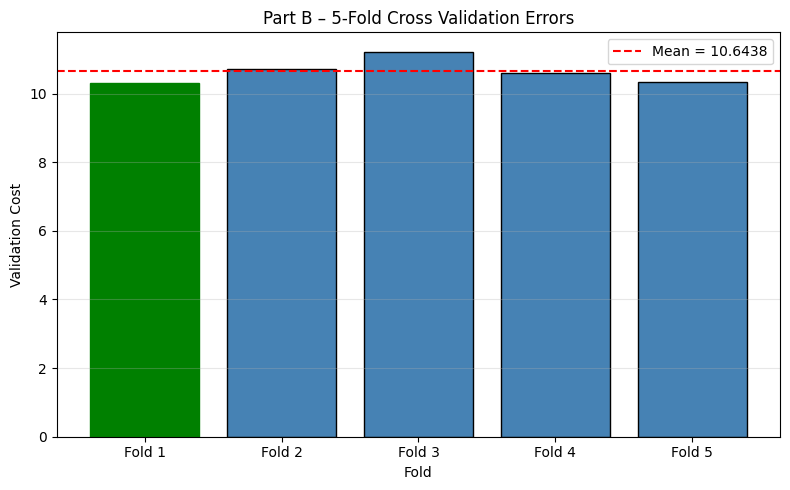

In [9]:
def run_part_b():
    """Part B: 5-fold cross validation on the CCPP dataset."""
    cfg = CCPP_CONFIG
    print("\n" + "=" * 65)
    print("  PART B: 5-FOLD CROSS VALIDATION (CCPP)")
    print("=" * 65 + "\n")

    X_raw, y_raw = load_ccpp_data(cfg["file_path"])

    fold_results = []
    all_thetas = []

    for fold_idx, (X_tr, y_tr, X_va, y_va) in enumerate(
        k_fold_split(X_raw, y_raw, k=5)
    ):
        print(f"\n--- Fold {fold_idx + 1} / 5 ---")

        # Normalize using THIS fold's training statistics only
        X_tr_norm, X_va_norm, _ = normalize_features(X_tr, X_va)
        X_tr_b = add_bias(X_tr_norm)
        X_va_b = add_bias(X_va_norm)

        y_tr_v = y_tr.reshape(-1, 1)
        y_va_v = y_va.reshape(-1, 1)

        theta, train_costs, val_costs = train_model(
            X_tr_b, y_tr_v, X_va_b, y_va_v,
            alpha=cfg["learning_rate"], num_iters=cfg["iterations"]
        )

        fold_results.append({
            "fold": fold_idx + 1,
            "train_cost": train_costs[-1],
            "val_cost": val_costs[-1],
        })
        all_thetas.append(theta)

    # ── Summary table ──
    print("\n" + "=" * 55)
    print("  5-FOLD CROSS VALIDATION RESULTS")
    print("=" * 55)
    print(f"  {'Fold':<6} {'Train Cost':<16} {'Val Cost':<16}")
    print("  " + "─" * 40)
    for r in fold_results:
        print(f"  {r['fold']:<6} {r['train_cost']:<16.6f} {r['val_cost']:<16.6f}")

    train_costs_all = [r["train_cost"] for r in fold_results]
    val_costs_all = [r["val_cost"] for r in fold_results]
    print("  " + "─" * 40)
    print(f"  {'Mean':<6} {np.mean(train_costs_all):<16.6f} {np.mean(val_costs_all):<16.6f}")
    print(f"  {'Std':<6} {np.std(train_costs_all):<16.6f} {np.std(val_costs_all):<16.6f}")
    print("=" * 55)

    # Best fold
    best_fold_idx = np.argmin(val_costs_all)
    best_theta = all_thetas[best_fold_idx]
    print(f"\n  Best fold: {best_fold_idx + 1}  "
          f"(val cost = {val_costs_all[best_fold_idx]:.6f})")
    print_parameters(best_theta, f"(Best – Fold {best_fold_idx + 1})")

    # Bar plot of fold validation errors
    plt.figure(figsize=(8, 5))
    folds_labels = [f"Fold {i+1}" for i in range(5)]
    bars = plt.bar(folds_labels, val_costs_all, color="steelblue", edgecolor="black")
    bars[best_fold_idx].set_color("green")
    plt.axhline(y=np.mean(val_costs_all), color="red", linestyle="--",
                label=f"Mean = {np.mean(val_costs_all):.4f}")
    plt.xlabel("Fold")
    plt.ylabel("Validation Cost")
    plt.title("Part B – 5-Fold Cross Validation Errors")
    plt.legend()
    plt.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    path = os.path.join(PLOTS_DIR, "partB_cv_errors.png")
    plt.savefig(path, dpi=150)
    print(f"[INFO] Plot saved: {path}")
    plt.show()

    return best_theta


# ── Run Part B ──
theta_b = run_part_b()

## Section 7: Part C — Polynomial Regression (data_02b.csv)

**Dataset:** 392 samples, 1 feature, 1 target (no header).

We fit polynomials of degree **d = 1, 2, 3** and find the best using validation error.

The model for degree $d$:

$$\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \cdots + \theta_d x^d$$

This is still **linear regression** — linear in the parameters $\boldsymbol{\theta}$.  
We just expand the features first, then normalize, then run gradient descent.

**Outputs:**
- Raw data scatter plot
- All 3 fitted curves on one graph
- Bar chart comparing validation errors (best highlighted green)
- Error curves (train + val) for each degree


  PART C: POLYNOMIAL REGRESSION (data_02b.csv)

[INFO] Loaded 392 samples from data_02b.csv
[INFO] Plot saved: d:\Downloads\DUCSE Documents\4-1\Mine\CSE-4125 Introduction to Machine Learning\Lab\CSE-4125-Introduction-to-Machine-Learning\lab2\plots\partC_raw_data.png


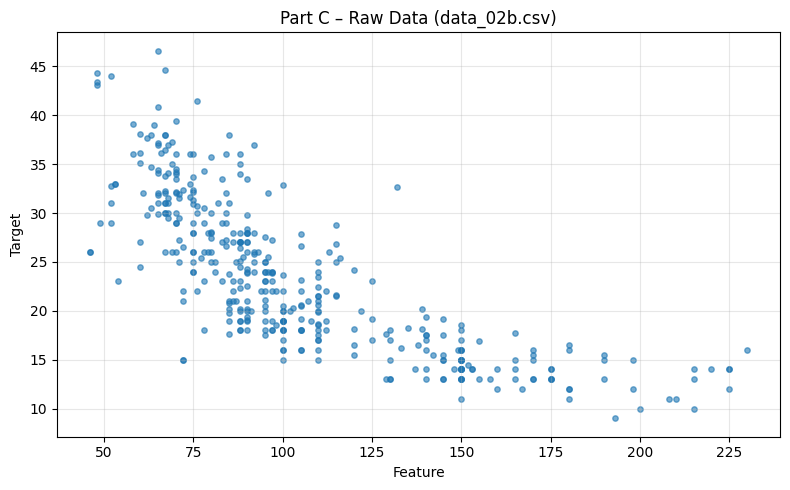


─────────────────────────────────────────────
  Polynomial Degree d = 1
─────────────────────────────────────────────
[TRAIN] Final training cost   = 11.986123
[TRAIN] Final validation cost = 11.945686

  LEARNED PARAMETERS (degree 1)
  theta_0  =      23.167093
  theta_1  =      -6.146642


─────────────────────────────────────────────
  Polynomial Degree d = 2
─────────────────────────────────────────────
[TRAIN] Final training cost   = 11.413724
[TRAIN] Final validation cost = 11.625638

  LEARNED PARAMETERS (degree 2)
  theta_0  =      23.167093
  theta_1  =      -7.422627
  theta_2  =       1.488389


─────────────────────────────────────────────
  Polynomial Degree d = 3
─────────────────────────────────────────────
[TRAIN] Final training cost   = 9.977046
[TRAIN] Final validation cost = 10.543871

  LEARNED PARAMETERS (degree 3)
  theta_0  =      23.167093
  theta_1  =      -8.750580
  theta_2  =      -1.498233
  theta_3  =       4.525605


  BEST DEGREE: d = 3  (val cost = 10.

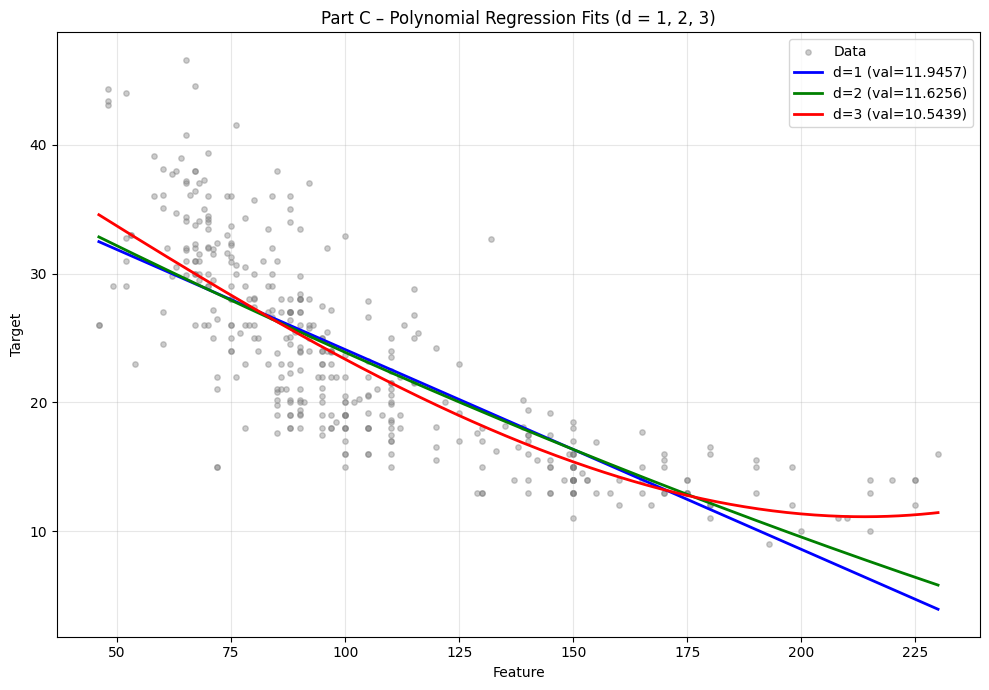

[INFO] Plot saved: d:\Downloads\DUCSE Documents\4-1\Mine\CSE-4125 Introduction to Machine Learning\Lab\CSE-4125-Introduction-to-Machine-Learning\lab2\plots\partC_val_errors_bar.png


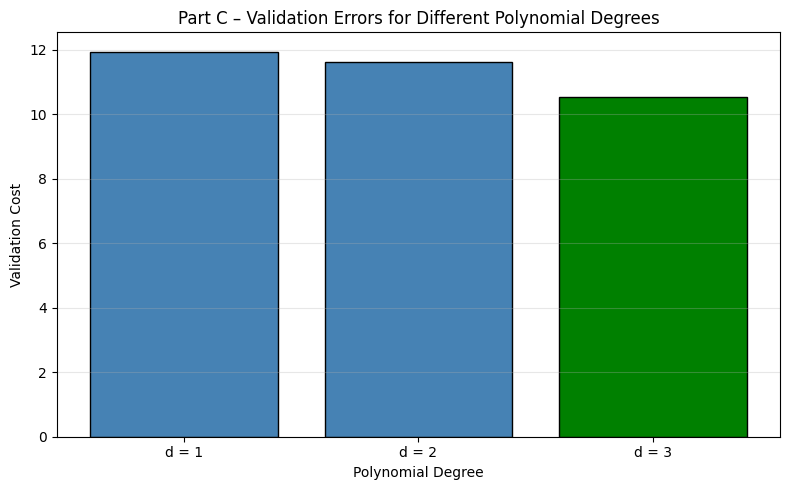

[INFO] Plot saved: d:\Downloads\DUCSE Documents\4-1\Mine\CSE-4125 Introduction to Machine Learning\Lab\CSE-4125-Introduction-to-Machine-Learning\lab2\plots\partC_error_curves_all.png


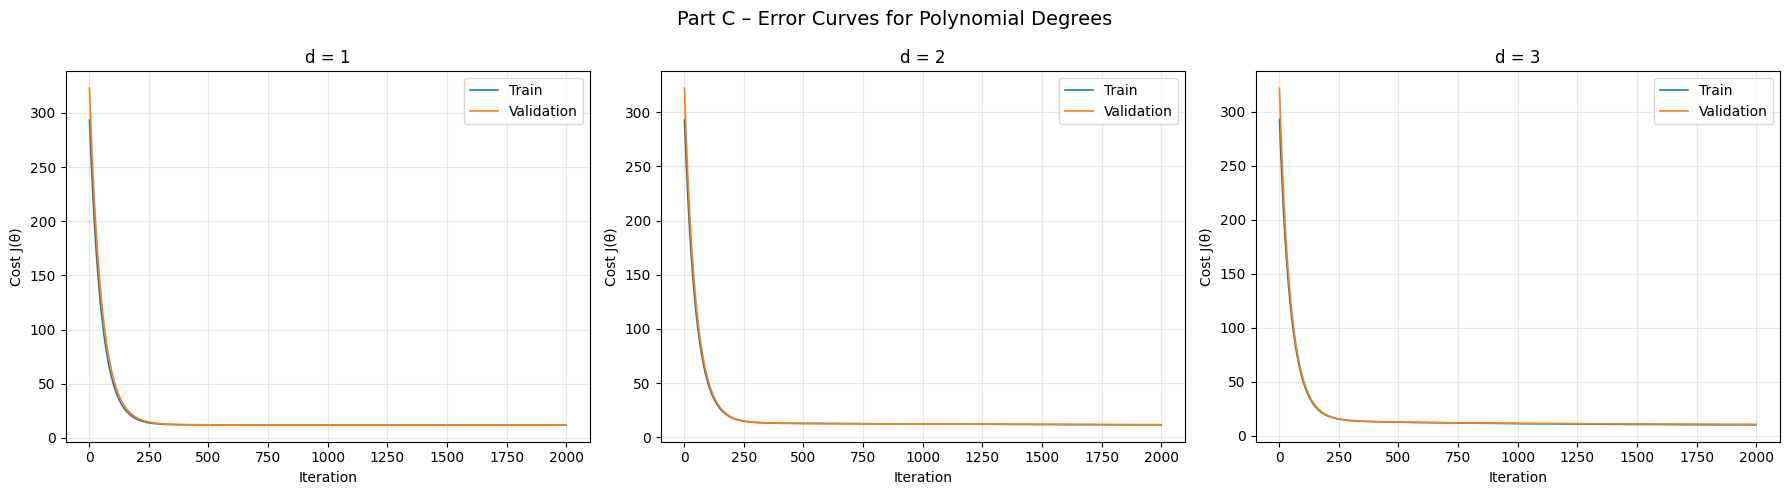

In [16]:
def run_part_c():
    """Part C: Polynomial regression on data_02b.csv."""
    cfg = POLY_CONFIG
    print("\n" + "=" * 65)
    print("  PART C: POLYNOMIAL REGRESSION (data_02b.csv)")
    print("=" * 65 + "\n")

    # ── 1. Load and plot data ──
    x_raw, y_raw = load_csv_data(cfg["file_path"])

    plot_scatter(
        x_raw, y_raw,
        xlabel="Feature", ylabel="Target",
        title="Part C – Raw Data (data_02b.csv)",
        save_as="partC_raw_data.png"
    )

    # ── 2. Train/validation split ──
    X_1d = x_raw.reshape(-1, 1)
    X_train_raw, y_train_raw, X_val_raw, y_val_raw = train_test_split(
        X_1d, y_raw, train_ratio=cfg["train_ratio"]
    )
    x_train = X_train_raw.flatten()
    x_val = X_val_raw.flatten()
    y_train = y_train_raw.reshape(-1, 1)
    y_val = y_val_raw.reshape(-1, 1)

    # ── 3. Train for each polynomial degree ──
    results = {}

    for d in cfg["degrees"]:
        print(f"\n{'─' * 45}")
        print(f"  Polynomial Degree d = {d}")
        print(f"{'─' * 45}")

        # Build polynomial features: [x, x², ..., x^d]
        X_train_poly = build_polynomial_features(x_train, d)
        X_val_poly = build_polynomial_features(x_val, d)

        # Normalize (CRITICAL: x³ for x=200 is 8,000,000 — must normalize!)
        X_train_norm, X_val_norm, norm_params = normalize_features(
            X_train_poly, X_val_poly
        )

        # Add bias column
        X_train_b = add_bias(X_train_norm)
        X_val_b = add_bias(X_val_norm)

        # Train
        theta, train_costs, val_costs = train_model(
            X_train_b, y_train, X_val_b, y_val,
            alpha=cfg["learning_rate"], num_iters=cfg["iterations"]
        )

        results[d] = {
            "theta": theta,
            "train_costs": train_costs,
            "val_costs": val_costs,
            "norm_params": norm_params,
            "val_error": val_costs[-1],
            "train_error": train_costs[-1],
        }

        print_parameters(theta, f"(degree {d})")

    # ── 4. Find best degree ──
    best_d = min(results, key=lambda d: results[d]["val_error"])
    print(f"\n{'=' * 55}")
    print(f"  BEST DEGREE: d = {best_d}  "
          f"(val cost = {results[best_d]['val_error']:.6f})")
    print(f"{'=' * 55}")
    print_parameters(results[best_d]["theta"], f"(BEST, degree {best_d})")

    # ── 5. All three fitted curves on one graph ──
    plt.figure(figsize=(10, 7))
    plt.scatter(x_raw, y_raw, s=15, alpha=0.4, color="gray", label="Data")

    x_line = np.linspace(x_raw.min(), x_raw.max(), 300)
    colors = {1: "blue", 2: "green", 3: "red"}

    for d in cfg["degrees"]:
        r = results[d]
        X_line_poly = build_polynomial_features(x_line, d)
        # Apply same normalization that was fit on training data
        X_line_norm = (X_line_poly - r["norm_params"]["mean"]) / r["norm_params"]["std"]
        X_line_b = add_bias(X_line_norm)
        y_pred = X_line_b @ r["theta"]

        plt.plot(x_line, y_pred.flatten(), color=colors[d], linewidth=2,
                 label=f"d={d} (val={r['val_error']:.4f})")

    plt.xlabel("Feature")
    plt.ylabel("Target")
    plt.title("Part C – Polynomial Regression Fits (d = 1, 2, 3)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    path = os.path.join(PLOTS_DIR, "partC_poly_fits.png")
    plt.savefig(path, dpi=150)
    print(f"[INFO] Plot saved: {path}")
    plt.show()

    # ── 6. Bar chart of validation errors ──
    plt.figure(figsize=(8, 5))
    degrees_str = [f"d = {d}" for d in cfg["degrees"]]
    val_errors = [results[d]["val_error"] for d in cfg["degrees"]]
    bar_colors = ["green" if d == best_d else "steelblue" for d in cfg["degrees"]]
    plt.bar(degrees_str, val_errors, color=bar_colors, edgecolor="black")
    plt.xlabel("Polynomial Degree")
    plt.ylabel("Validation Cost")
    plt.title("Part C – Validation Errors for Different Polynomial Degrees")
    plt.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    path = os.path.join(PLOTS_DIR, "partC_val_errors_bar.png")
    plt.savefig(path, dpi=150)
    print(f"[INFO] Plot saved: {path}")
    plt.show()

    # ── 7. Training & validation error curves for all degrees ──
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for idx, d in enumerate(cfg["degrees"]):
        ax = axes[idx]
        r = results[d]
        iters = range(1, len(r["train_costs"]) + 1)
        ax.plot(iters, r["train_costs"], label="Train", linewidth=1.2)
        ax.plot(iters, r["val_costs"], label="Validation", linewidth=1.2)
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Cost J(θ)")
        ax.set_title(f"d = {d}")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle("Part C – Error Curves for Polynomial Degrees", fontsize=14)
    plt.tight_layout()
    path = os.path.join(PLOTS_DIR, "partC_error_curves_all.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"[INFO] Plot saved: {path}")
    plt.show()

    return results


# ── Run Part C ──
poly_results = run_part_c()

## Section 8: Summary of Results

Review learned parameters and cost comparison across all three parts.

In [11]:
print("\n" + "=" * 65)
print("  LAB 02 — COMPLETE RESULTS SUMMARY")
print("=" * 65)

print("\n── Part A: Multi-variable Linear Regression (CCPP) ──")
print("  Best model uses Z-score normalization (lr=0.01)")
print_parameters(theta_a, "(Part A – With Normalization)")

print("\n── Part B: 5-Fold Cross Validation (CCPP) ──")
print("  Parameters from best fold:")
print_parameters(theta_b, "(Part B – Best Fold)")

print("\n── Part C: Polynomial Regression (data_02b.csv) ──")
best_d_final = min(poly_results, key=lambda d: poly_results[d]["val_error"])
print(f"  Best polynomial degree: d = {best_d_final}")
for d in [1, 2, 3]:
    r = poly_results[d]
    marker = " ← BEST" if d == best_d_final else ""
    print(f"  d={d}: train={r['train_error']:.6f}  val={r['val_error']:.6f}{marker}")
print_parameters(poly_results[best_d_final]["theta"], f"(Part C – Best, degree {best_d_final})")

print("\n" + "=" * 65)
print("  ALL PARTS COMPLETE — All plots saved to:", PLOTS_DIR)
print("=" * 65)


  LAB 02 — COMPLETE RESULTS SUMMARY

── Part A: Multi-variable Linear Regression (CCPP) ──
  Best model uses Z-score normalization (lr=0.01)

  LEARNED PARAMETERS (Part A – With Normalization)
  theta_0  =     454.391191
  theta_1  =     -13.042431
  theta_2  =      -4.210818
  theta_3  =       0.719397
  theta_4  =      -1.752833


── Part B: 5-Fold Cross Validation (CCPP) ──
  Parameters from best fold:

  LEARNED PARAMETERS (Part B – Best Fold)
  theta_0  =     454.431260
  theta_1  =     -13.088198
  theta_2  =      -4.191568
  theta_3  =       0.678207
  theta_4  =      -1.762181


── Part C: Polynomial Regression (data_02b.csv) ──
  Best polynomial degree: d = 3
  d=1: train=11.986123  val=11.945686
  d=2: train=11.413724  val=11.625638
  d=3: train=9.977046  val=10.543871 ← BEST

  LEARNED PARAMETERS (Part C – Best, degree 3)
  theta_0  =      23.167093
  theta_1  =      -8.750580
  theta_2  =      -1.498233
  theta_3  =       4.525605


  ALL PARTS COMPLETE — All plots saved t

## Section 9: Detailed Results — Values Mapped to Dataset & Comparison Tables

In [14]:
feature_names = CCPP_CONFIG["feature_names"]
target_name   = CCPP_CONFIG["target_name"]

# ─── helper to print a table row ───────────────────────────────────────────
def table_row(*cols, widths):
    return "  " + "".join(str(c).ljust(w) for c, w in zip(cols, widths))

def table_sep(widths, char="─"):
    return "  " + char * sum(widths)

# ═══════════════════════════════════════════════════════════════════════════
# TABLE 1 — Part A: Learned Parameters Mapped to Feature Names
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  TABLE 1 — PART A: Learned Parameters (CCPP, With Normalization)")
print("=" * 70)

w = [6, 30, 18, 18]
print(table_row("θ", "Feature / Variable", "Value (norm.space)", "Interpretation", widths=w))
print(table_sep(w))

param_labels = ["Intercept (bias)"] + feature_names
for i, (label, val) in enumerate(zip(param_labels, theta_a.flatten())):
    interp = "baseline PE when all features = their mean" if i == 0 else \
             ("↑ temp → ↓ output" if i == 1 else
              "↑ vacuum → ↓ output" if i == 2 else
              "↑ pressure → slight ↑ output" if i == 3 else
              "↑ humidity → ↓ output")
    print(table_row(f"θ{i}", label, f"{val:+.6f}", interp, widths=w))

print(table_sep(w))
print(f"  Target variable: {target_name}")

# ═══════════════════════════════════════════════════════════════════════════
# TABLE 2 — Part A: Normalization Comparison
# ═══════════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 70)
print("  TABLE 2 — PART A: With vs Without Normalization")
print("=" * 70)

w2 = [30, 12, 12, 14, 16]
print(table_row("Setting", "LR (α)", "Iters", "Final Train J", "Final Val J", widths=w2))
print(table_sep(w2))

# Re-run briefly to get both sets of final costs (already in scope from run_part_a)
# We'll retrieve them from the returned values via a quick re-call
cfg_a = CCPP_CONFIG
X_r, y_r = load_ccpp_data(cfg_a["file_path"])
X_tr_r, y_tr_r, X_v_r, y_v_r = train_test_split(X_r, y_r, train_ratio=cfg_a["train_ratio"])
y_tr_r = y_tr_r.reshape(-1, 1);  y_v_r = y_v_r.reshape(-1, 1)

# Without norm
_, tc_nn, vc_nn = train_model(add_bias(X_tr_r), y_tr_r, add_bias(X_v_r), y_v_r,
                               alpha=1e-7, num_iters=cfg_a["iterations"])
# With norm
Xn_tr, Xn_v, _ = normalize_features(X_tr_r, X_v_r)
_, tc_n, vc_n = train_model(add_bias(Xn_tr), y_tr_r, add_bias(Xn_v), y_v_r,
                              alpha=cfg_a["learning_rate"], num_iters=cfg_a["iterations"])

print(table_row("Without normalization", "1e-7", cfg_a["iterations"],
                f"{tc_nn[-1]:.4f}", f"{vc_nn[-1]:.4f}", widths=w2))
print(table_row("With Z-score normalization", "0.01", cfg_a["iterations"],
                f"{tc_n[-1]:.4f}", f"{vc_n[-1]:.4f}", widths=w2))
print(table_sep(w2))
improvement = ((vc_nn[-1] - vc_n[-1]) / vc_nn[-1]) * 100
print(f"  → Normalization reduces validation cost by {improvement:.1f}%")

# ═══════════════════════════════════════════════════════════════════════════
# TABLE 3 — Part B: Per-Fold Cross Validation Results
# ═══════════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 70)
print("  TABLE 3 — PART B: 5-Fold Cross Validation Results (CCPP)")
print("=" * 70)

fold_train_costs = []
fold_val_costs   = []
fold_thetas      = []

X_cv, y_cv = load_ccpp_data(cfg_a["file_path"])
for X_tr_f, y_tr_f, X_va_f, y_va_f in k_fold_split(X_cv, y_cv, k=5):
    Xn_tr_f, Xn_va_f, _ = normalize_features(X_tr_f, X_va_f)
    th_f, tc_f, vc_f = train_model(add_bias(Xn_tr_f), y_tr_f.reshape(-1,1),
                                    add_bias(Xn_va_f), y_va_f.reshape(-1,1),
                                    alpha=cfg_a["learning_rate"],
                                    num_iters=cfg_a["iterations"])
    fold_train_costs.append(tc_f[-1])
    fold_val_costs.append(vc_f[-1])
    fold_thetas.append(th_f)

best_fold = int(np.argmin(fold_val_costs))

w3 = [8, 16, 16, 10]
print(table_row("Fold", "Train Cost J", "Val Cost J", "Status", widths=w3))
print(table_sep(w3))
for i in range(5):
    status = "★ BEST" if i == best_fold else ""
    print(table_row(f"  {i+1}", f"{fold_train_costs[i]:.6f}",
                    f"{fold_val_costs[i]:.6f}", status, widths=w3))
print(table_sep(w3))
print(table_row("Mean", f"{np.mean(fold_train_costs):.6f}",
                f"{np.mean(fold_val_costs):.6f}", "", widths=w3))
print(table_row("Std", f"{np.std(fold_train_costs):.6f}",
                f"{np.std(fold_val_costs):.6f}", "", widths=w3))
print(table_sep(w3))

# Parameters from best fold mapped to features
print(f"\n  Best Fold {best_fold + 1} — Parameters Mapped to Features:")
w3b = [6, 30, 16]
print(table_row("θ", "Feature / Variable", "Value", widths=w3b))
print(table_sep(w3b))
for i, (label, val) in enumerate(zip(param_labels, fold_thetas[best_fold].flatten())):
    print(table_row(f"θ{i}", label, f"{val:+.6f}", widths=w3b))
print(table_sep(w3b))

# ═══════════════════════════════════════════════════════════════════════════
# TABLE 4 — Part A vs Part B: Parameter Comparison
# ═══════════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 70)
print("  TABLE 4 — PART A vs PART B: Parameter Comparison (CCPP)")
print("=" * 70)

w4 = [6, 28, 18, 18, 12]
print(table_row("θ", "Feature", "Part A (80/20 split)",
                f"Part B (Fold {best_fold+1})", "Δ Diff", widths=w4))
print(table_sep(w4))
for i, (label, va, vb) in enumerate(zip(param_labels,
                                         theta_a.flatten(),
                                         fold_thetas[best_fold].flatten())):
    print(table_row(f"θ{i}", label, f"{va:+.6f}", f"{vb:+.6f}",
                    f"{abs(va-vb):.4f}", widths=w4))
print(table_sep(w4))
print(f"  Val Cost → Part A: {vc_n[-1]:.6f}   |   "
      f"Part B Best Fold: {fold_val_costs[best_fold]:.6f}")

# ═══════════════════════════════════════════════════════════════════════════
# TABLE 5 — Part C: Polynomial Degree Comparison
# ═══════════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 70)
print("  TABLE 5 — PART C: Polynomial Regression Comparison (data_02b.csv)")
print("=" * 70)

best_d_c = min(poly_results, key=lambda d: poly_results[d]["val_error"])

w5 = [10, 16, 16, 12, 12]
print(table_row("Degree d", "Train Cost J", "Val Cost J",
                "# Params", "Status", widths=w5))
print(table_sep(w5))
for d in [1, 2, 3]:
    r = poly_results[d]
    status = "★ BEST" if d == best_d_c else ""
    n_params = d + 1   # d features + 1 bias
    print(table_row(f"  d = {d}", f"{r['train_error']:.6f}",
                    f"{r['val_error']:.6f}", f"{n_params}", status, widths=w5))
print(table_sep(w5))

# Parameters for each degree mapped to power terms
for d in [1, 2, 3]:
    r = poly_results[d]
    marker = " ★ BEST" if d == best_d_c else ""
    print(f"\n  d = {d}{marker} — Learned Parameters:")
    poly_labels = ["Intercept (θ₀)"] + [f"x^{p} coefficient (θ{p})" for p in range(1, d+1)]
    w5b = [6, 30, 16]
    print(table_row("θ", "Term", "Value", widths=w5b))
    print(table_sep(w5b))
    for i, (label, val) in enumerate(zip(poly_labels, r["theta"].flatten())):
        print(table_row(f"θ{i}", label, f"{val:+.6f}", widths=w5b))
    print(table_sep(w5b))

# ═══════════════════════════════════════════════════════════════════════════
# TABLE 6 — Overall Summary: All Parts
# ═══════════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 70)
print("  TABLE 6 — OVERALL SUMMARY: All Parts Compared")
print("=" * 70)

w6 = [28, 12, 12, 22]
print(table_row("Experiment", "Train J", "Val J", "Best Config", widths=w6))
print(table_sep(w6))
print(table_row("Part A (no normalization)",
                f"{tc_nn[-1]:.4f}", f"{vc_nn[-1]:.4f}",
                "lr=1e-7, iters=1500", widths=w6))
print(table_row("Part A (with normalization)",
                f"{tc_n[-1]:.4f}", f"{vc_n[-1]:.4f}",
                "lr=0.01, iters=1500  ★", widths=w6))
print(table_row(f"Part B (best fold {best_fold+1}/5, CV)",
                f"{fold_train_costs[best_fold]:.4f}",
                f"{fold_val_costs[best_fold]:.4f}",
                f"lr=0.01, iters=1500", widths=w6))
print(table_row("Part B (CV mean across 5 folds)",
                f"{np.mean(fold_train_costs):.4f}",
                f"{np.mean(fold_val_costs):.4f}",
                f"±{np.std(fold_val_costs):.4f} std", widths=w6))
for d in [1, 2, 3]:
    r = poly_results[d]
    marker = " ★" if d == best_d_c else ""
    print(table_row(f"Part C poly d={d}",
                    f"{r['train_error']:.4f}", f"{r['val_error']:.4f}",
                    f"lr=0.01, iters=2000{marker}", widths=w6))
print(table_sep(w6))
print(f"\n  ★ = best configuration in each part")


  TABLE 1 — PART A: Learned Parameters (CCPP, With Normalization)
  θ     Feature / Variable            Value (norm.space)Interpretation    
  ────────────────────────────────────────────────────────────────────────
  θ0    Intercept (bias)              +454.391191       baseline PE when all features = their mean
  θ1    AT (Temperature)              -13.042431        ↑ temp → ↓ output 
  θ2    V (Exhaust Vacuum)            -4.210818         ↑ vacuum → ↓ output
  θ3    AP (Ambient Pressure)         +0.719397         ↑ pressure → slight ↑ output
  θ4    RH (Relative Humidity)        -1.752833         ↑ humidity → ↓ output
  ────────────────────────────────────────────────────────────────────────
  Target variable: PE (Net Energy Output)


  TABLE 2 — PART A: With vs Without Normalization
  Setting                       LR (α)      Iters       Final Train J Final Val J     
  ────────────────────────────────────────────────────────────────────────────────────
[INFO] Loaded CCPP data: 95